In [1]:
import pandas as pd
import matplotlib.pyplot as plt

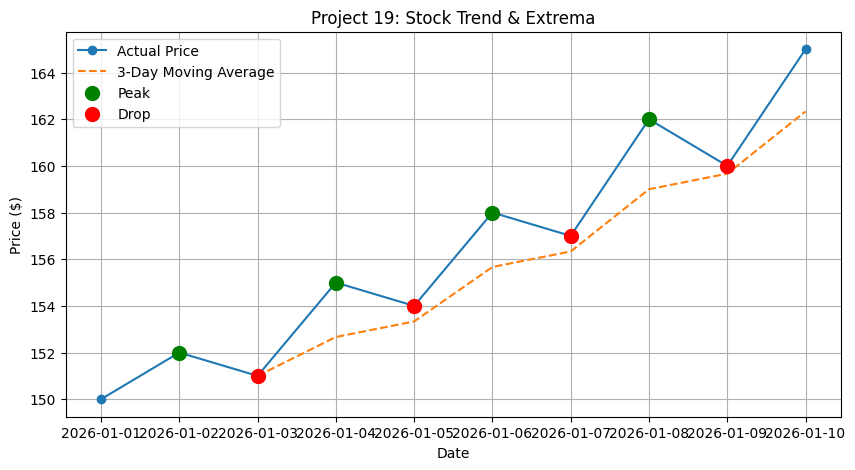

In [2]:
# 1. Create a simple 10-day Stock Dataset
data = {
    'Date': pd.date_range(start="2026-01-01", periods=10),
    'Price': [150, 152, 151, 155, 154, 158, 157, 162, 160, 165]
}
df = pd.DataFrame(data)
df.set_index('Date', inplace=True)

# 2. Calculate a 3-Day Moving Average
df['Moving_Avg'] = df['Price'].rolling(window=3).mean()

# 3. Identify Peaks & Drops (Comparing today's price with yesterday and tomorrow)
df['Is_Peak'] = (df['Price'] > df['Price'].shift(1)) & (df['Price'] > df['Price'].shift(-1))
df['Is_Drop'] = (df['Price'] < df['Price'].shift(1)) & (df['Price'] < df['Price'].shift(-1))

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Price'], label='Actual Price', marker='o')
plt.plot(df.index, df['Moving_Avg'], label='3-Day Moving Average', linestyle='--')

# Highlight Peaks (Green) and Drops (Red)
peaks = df[df['Is_Peak']]
drops = df[df['Is_Drop']]
plt.scatter(peaks.index, peaks['Price'], color='green', s=100, label='Peak', zorder=5)
plt.scatter(drops.index, drops['Price'], color='red', s=100, label='Drop', zorder=5)

plt.title('Project 19: Stock Trend & Extrema')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()